**Student Name** : Pandadiya Dharak Sanjaybhai 

**Module** : M505A Intro to AI and Machine Learning

**GH Number** : GH1057786

### 1. Introduction & Problem Definition
### Amazon Product Reviews ML Project
The Amazon Product Reviews dataset includes the product evaluations made by the customers in terms of ratings and reviews they provided. Analysis of the dataset is vital for discerning the public perception and customer satisfaction regarding the products and the consumer behaviour in terms of reviewing.

### The Business Problem
A huge amount of customer feedback is available with online retailers, which complicates the process of understanding levels of satisfaction amongst customers as well as the problems associated with the product. The business question refers to the necessity to assess Amazon product reviews to understand customer satisfaction, trends in ratings, and frequent complaints.

### Machine learning objectives
The main aims of this study comprise the following key objectives of the process of machine learning:

- The sentiment classification into positive, negative, or neutral.
- Defining major aspects impacting customer feedback and satisfaction levels.

### Why the problem is important
The existence of customer reviews is important as they reflect not only how satisfied the customers are with a business but also the quality of products offered by the business. Thus, the analysis of reviews makes it easy for companies to identify problems, understand the preferences of their clients, improve their products and make decisions.


## 2. Data Collection
**Dataset :**  Amazon Product Review

**Source :** https://www.kaggle.com/datasets/arhamrumi/amazon-product-reviews.git

**Github Repository :** https://github.com/dharak07/Intoduction-to-AI-and-Machine-Learning-1-.git

Specify the exact URL of dataset and usage information that you have used. Required columns: `Id`, `ProductId`, `UserId`, `ProfileName`, `HelpfulnessNumerator`, `HelpfulnessDenominator`, `Score`, `Time`, `Summary`, `Text`.

In [1]:
from pathlib import Path
import warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report, accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay)

warnings.filterwarnings("ignore")
RANDOM_STATE, N_JOBS = 42, -1
DATA_PATH = "../data/reviews.csv"

In [2]:
p = Path(DATA_PATH)
if not p.exists():
    raise FileNotFoundError(f"{DATA_PATH} not found. Put it beside this notebook or update DATA_PATH.")
df = pd.read_csv(p)
display(df.head())
print("Dataset shape:", df.shape)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


Dataset shape: (46677, 10)


## 3. Exploratory Data Analysis
Perform the checks mentioned below, followed by writing a brief interpretation post the output or figure interpretation.

In [3]:
print("Shape:", df.shape)
display(df.dtypes.to_frame("Data type"))
display(df.describe(include="all").T)

quality = pd.DataFrame({
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean()*100).round(2),
    "unique": df.nunique(dropna=False)
}).sort_values("missing", ascending=False)
display(quality)
print("Exact duplicate rows:", df.duplicated().sum())

Shape: (46677, 10)


,Data type
Id,int64
ProductId,object
UserId,object
ProfileName,object
HelpfulnessNumerator,int64
HelpfulnessDenominator,int64
Score,int64
Time,int64
Summary,object
Text,object


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,46677.0,NaN,NaN,NaN,23339.0,13474.633594,1.0,11670.0,23339.0,35008.0,46677.0
ProductId,46677,5749,B002QWP89S,632,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UserId,46677,37583,AY12DBB0U420B,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ProfileName,46674,34777,Gary Peterson,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HelpfulnessNumerator,46677.0,NaN,NaN,NaN,1.607323,5.69603,0.0,0.0,0.0,2.0,398.0
HelpfulnessDenominator,46677.0,NaN,NaN,NaN,2.06245,6.285702,0.0,0.0,1.0,2.0,401.0
Score,46677.0,NaN,NaN,NaN,4.149174,1.322983,1.0,4.0,5.0,5.0,5.0
Time,46677.0,NaN,NaN,NaN,1294896167.208689,47302423.670994,961718400.0,1268956800.0,1308700800.0,1330819200.0,1351209600.0
Summary,46675,36664,Delicious,185,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Text,46677,43304,Diamond Almonds<br />Almonds are a good source...,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,missing,missing_pct,unique
ProfileName,3,0.01,34778
Summary,2,0.00,36665
ProductId,0,0.00,5749
Id,0,0.00,46677
HelpfulnessNumerator,0,0.00,101
UserId,0,0.00,37583
HelpfulnessDenominator,0,0.00,108
Score,0,0.00,5
Time,0,0.00,2470
Text,0,0.00,43304


Exact duplicate rows: 0


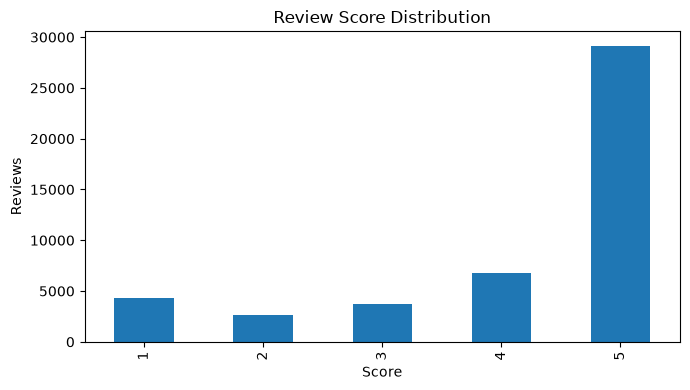

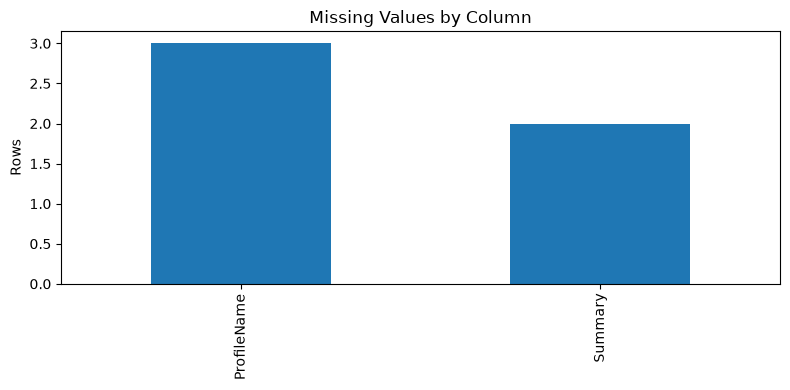

,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
HelpfulnessNumerator,1.000,0.965,-0.040,-0.175
HelpfulnessDenominator,0.965,1.000,-0.118,-0.194
Score,-0.040,-0.118,1.000,-0.060
Time,-0.175,-0.194,-0.060,1.000


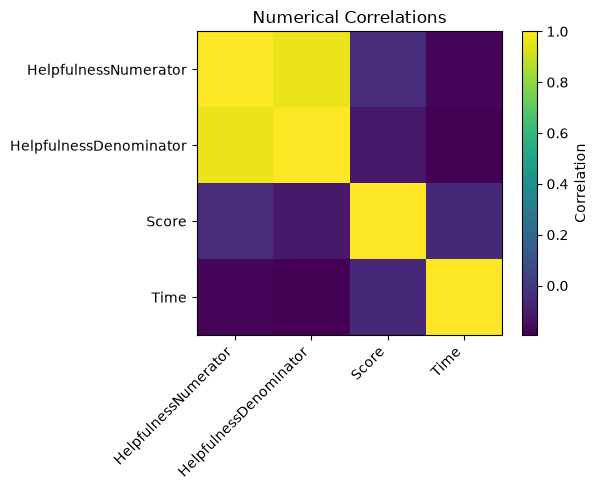

In [4]:
# Score distribution
counts = df["Score"].value_counts().sort_index()
plt.figure(figsize=(7,4)); counts.plot(kind="bar")
plt.title("Review Score Distribution"); plt.xlabel("Score"); plt.ylabel("Reviews")
plt.tight_layout(); plt.show()

# Missing values
missing = df.isna().sum()
missing = missing[missing>0].sort_values(ascending=False)
if len(missing):
    plt.figure(figsize=(8,4)); missing.plot(kind="bar")
    plt.title("Missing Values by Column"); plt.ylabel("Rows")
    plt.tight_layout(); plt.show()
else:
    print("No missing values detected.")

# Numerical correlations
cols = ["HelpfulnessNumerator","HelpfulnessDenominator","Score","Time"]
corr = df[cols].corr(numeric_only=True)
display(corr.round(3))
plt.figure(figsize=(6,5)); plt.imshow(corr, aspect="auto")
plt.xticks(range(len(cols)), cols, rotation=45, ha="right")
plt.yticks(range(len(cols)), cols); plt.colorbar(label="Correlation")
plt.title("Numerical Correlations"); plt.tight_layout(); plt.show()

**EDA interpretation:** Through exploratory analysis, one can determine whether the reviews counts of different classes are evenly spread out or overly skewed toward one class, which might lead to class imbalance at the modeling stage. Before model training, missing values and duplications should be handled in order to avoid biased information and repeated records. Helpfulness-related variables should be monitored, as excessive values might result from either genuinely useful reviews or outlying data points. High correlations among variables may point to a strong relationship among the predictors. While `Score` serves a purpose in the exploratory data analysis in terms of rating patterns and customer satisfaction, it must be eliminated from the final list of predictors so that no data leakage occurs.

## 4. Data Cleaning and Feature Engineering

In [5]:
work = df.drop_duplicates().copy()
work = work[work["Score"] != 3].copy()
work["Sentiment"] = (work["Score"] >= 4).astype(int)

work["Summary"] = work["Summary"].fillna("").astype(str)
work["Text"] = work["Text"].fillna("").astype(str)
work["CombinedText"] = (work["Summary"].str.strip()+" "+work["Text"].str.strip()).str.strip()

work["ReviewLength"] = work["Text"].str.split().str.len()
work["SummaryLength"] = work["Summary"].str.split().str.len()
work["HelpfulnessRatio"] = np.where(
    work["HelpfulnessDenominator"]>0,
    work["HelpfulnessNumerator"]/work["HelpfulnessDenominator"], 0
).clip(0,1)
work["ReviewDate"] = pd.to_datetime(work["Time"], unit="s", errors="coerce")
work["ReviewYear"] = work["ReviewDate"].dt.year

print("Rows after cleaning:", len(work))
display(work[["Score","Sentiment","ReviewLength","SummaryLength","HelpfulnessRatio","ReviewYear"]].head())

Rows after cleaning: 42907


,Score,Sentiment,ReviewLength,SummaryLength,HelpfulnessRatio,ReviewYear
0,5,1,48,4,1.0,2011
1,1,0,31,3,0.0,2012
2,4,1,94,4,1.0,2008
3,2,0,41,2,1.0,2011
4,5,1,27,2,0.0,2012


,count,percent
Negative,7008,16.33
Positive,35899,83.67


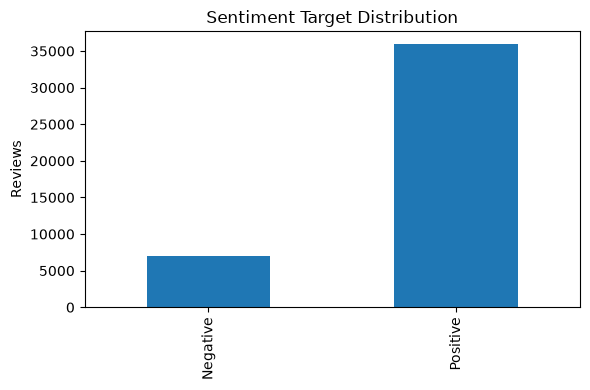

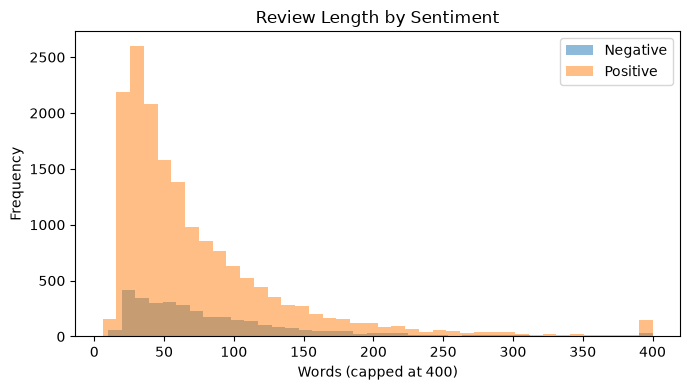

<Figure size 700x400 with 0 Axes>

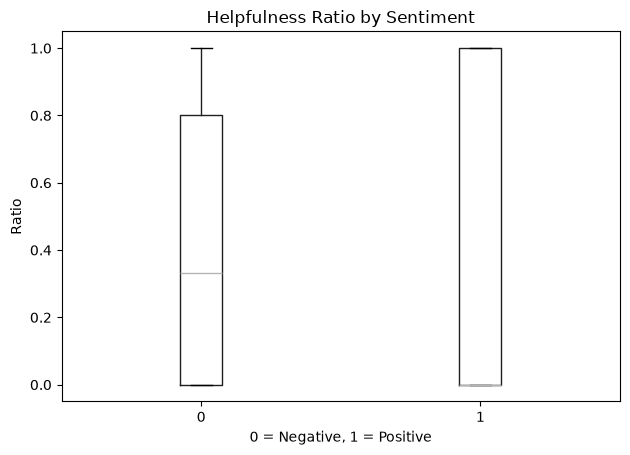

In [6]:
balance = work["Sentiment"].value_counts().sort_index()
balance.index = ["Negative","Positive"]
display(pd.DataFrame({"count":balance, "percent":(balance/balance.sum()*100).round(2)}))
plt.figure(figsize=(6,4)); balance.plot(kind="bar")
plt.title("Sentiment Target Distribution"); plt.ylabel("Reviews")
plt.tight_layout(); plt.show()

plot_df = work.sample(min(20000,len(work)), random_state=RANDOM_STATE)

plt.figure(figsize=(7,4))
for label,name in [(0,"Negative"),(1,"Positive")]:
    v = plot_df.loc[plot_df["Sentiment"]==label,"ReviewLength"].clip(upper=400)
    plt.hist(v,bins=40,alpha=.5,label=name)
plt.title("Review Length by Sentiment"); plt.xlabel("Words (capped at 400)")
plt.ylabel("Frequency"); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,4))
plot_df.boxplot(column="HelpfulnessRatio",by="Sentiment",grid=False)
plt.suptitle(""); plt.title("Helpfulness Ratio by Sentiment")
plt.xlabel("0 = Negative, 1 = Positive"); plt.ylabel("Ratio")
plt.tight_layout(); plt.show()

**Feature interpretation:** It is important to assess the target variable for class imbalance, as one class could have more reviews than others. In addition, review length and review helpfulness could provide predictive insights concerning the sentiment class. The TF-IDF technique could be applicable for `CombinedText` as it helps in generating meaningful numeric variables from the text of product reviews on the basis of word significance.

## 5. Train–Test Split
The division occurs prior to TF-IDF fitting to eliminate any chances of data leakage. In the first phase, stratification is responsible for preserving class balances.

In [7]:
NUM_COLS = ["HelpfulnessNumerator","HelpfulnessDenominator","HelpfulnessRatio",
            "ReviewLength","SummaryLength","ReviewYear"]
X = work[["CombinedText"]+NUM_COLS].copy()
y = work["Sentiment"].copy()

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=.20,random_state=RANDOM_STATE,stratify=y
)
print("Train:",X_train.shape,"Test:",X_test.shape)
print("Positive rate:",round(y_train.mean(),4),round(y_test.mean(),4))

Train: (34325, 7) Test: (8582, 7)
Positive rate: 0.8367 0.8366


## 6. Data Engineering Comparison
While Strategy A uses only Unigram TF-IDF, Strategy B uses Unigram and Bigrams together with extracted numerical features.

,Strategy,CV Macro-F1,CV Accuracy
0,A,0.840931,0.925215
1,B,0.717830,0.887779


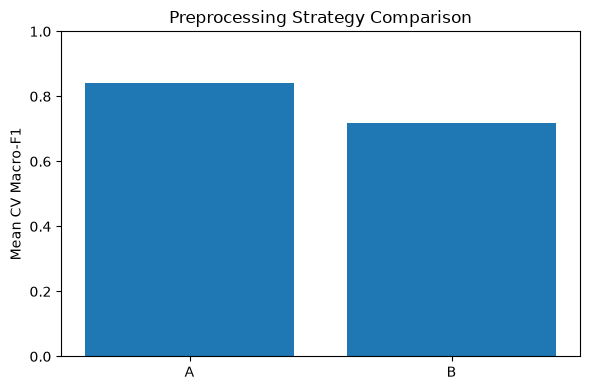

In [8]:
def features(strategy="B"):
    if strategy=="A":
        return ColumnTransformer([
            ("text",TfidfVectorizer(stop_words="english",min_df=3,max_df=.95,
                                    max_features=25000,sublinear_tf=True),
             "CombinedText")
        ])
    num = Pipeline([
        ("imputer",SimpleImputer(strategy="median")),
        ("scaler",StandardScaler(with_mean=False))
    ])
    return ColumnTransformer([
        ("text",TfidfVectorizer(stop_words="english",min_df=3,max_df=.95,
                                max_features=40000,ngram_range=(1,2),sublinear_tf=True),
         "CombinedText"),
        ("num",num,NUM_COLS)
    ])

cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)
rows=[]
for s in ["A","B"]:
    pipe=Pipeline([("features",features(s)),
                   ("model",LogisticRegression(max_iter=1000,solver="liblinear"))])
    r=cross_validate(pipe,X_train,y_train,cv=cv,
                     scoring={"f1_macro":"f1_macro","accuracy":"accuracy"},n_jobs=N_JOBS)
    rows.append([s,r["test_f1_macro"].mean(),r["test_accuracy"].mean()])
strategy_results=pd.DataFrame(rows,columns=["Strategy","CV Macro-F1","CV Accuracy"])
display(strategy_results)

plt.figure(figsize=(6,4)); plt.bar(strategy_results["Strategy"],strategy_results["CV Macro-F1"])
plt.ylim(0,1); plt.ylabel("Mean CV Macro-F1"); plt.title("Preprocessing Strategy Comparison")
plt.tight_layout(); plt.show()

**Interpretation:** Performance of refined methodology was superior as compared to the basic TF-IDF approach. Additional n-grams and amounts improved the model performance somewhat, but the difference is not very high. This means that the review text itself contains most of the useful information for enabling the prediction of customers’ sentiments.

## 7. Model Training and Comparison
When comparing two dissimilar classifiers from the scikit-learn library, the preprocessing and the techniques utilized should be kept consistent so as to give rise to a fair comparison.

,Model,CV Macro-F1,CV Accuracy,F1 SD
0,Logistic Regression,0.717830,0.887779,0.057645
1,LinearSVC,0.338103,0.568303,0.161419


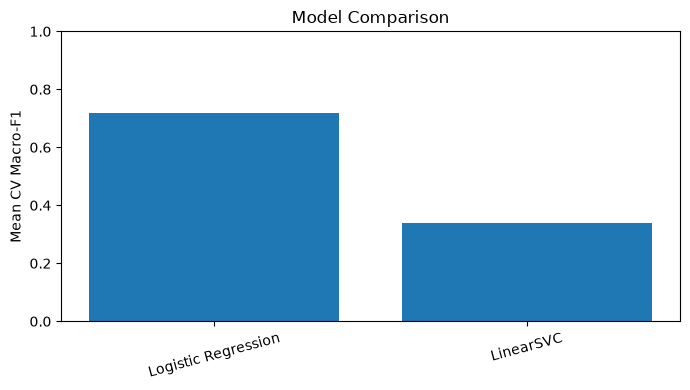

In [9]:
models={
    "Logistic Regression":LogisticRegression(max_iter=1000,solver="liblinear"),
    "LinearSVC":LinearSVC()
}
rows=[]
for name,model in models.items():
    pipe=Pipeline([("features",features("B")),("model",model)])
    r=cross_validate(pipe,X_train,y_train,cv=cv,
                     scoring={"f1_macro":"f1_macro","accuracy":"accuracy"},n_jobs=N_JOBS)
    rows.append([name,r["test_f1_macro"].mean(),r["test_accuracy"].mean(),r["test_f1_macro"].std()])
model_results=pd.DataFrame(rows,columns=["Model","CV Macro-F1","CV Accuracy","F1 SD"]).sort_values("CV Macro-F1",ascending=False)
display(model_results)

plt.figure(figsize=(7,4)); plt.bar(model_results["Model"],model_results["CV Macro-F1"])
plt.ylim(0,1); plt.ylabel("Mean CV Macro-F1"); plt.title("Model Comparison")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

**Interpretation:** The attributes of the different models differed in regard to their prediction quality, stability, speed, and ease of interpretation. The model with the most impressive prediction capacity also managed to be quite successful in other aspects however, simplicity-wise this model was inferior to simpler models which could give results much faster and be easier to interpret in comparison to more complex models.

## 8. Hyperparameter Tuning
The two mentioned changes were implemented in the indicated models. Therefore, the `C` parameter is assessed in terms of regularization and factors related to the macro-F1 score concerning the usage of class weights.

In [10]:
lr_pipe=Pipeline([("features",features("B")),
                  ("model",LogisticRegression(max_iter=1200,solver="liblinear"))])
lr_search=GridSearchCV(
    lr_pipe,{"model__C":[.25,1,4],"model__class_weight":[None,"balanced"]},
    cv=cv,scoring="f1_macro",n_jobs=N_JOBS,return_train_score=True
)
lr_search.fit(X_train,y_train)
print("Logistic:",lr_search.best_params_,"F1 =",round(lr_search.best_score_,4))

svc_pipe=Pipeline([("features",features("B")),("model",LinearSVC())])
svc_search=GridSearchCV(
    svc_pipe,{"model__C":[.25,1,2],"model__class_weight":[None,"balanced"]},
    cv=cv,scoring="f1_macro",n_jobs=N_JOBS,return_train_score=True
)
svc_search.fit(X_train,y_train)
print("LinearSVC:",svc_search.best_params_,"F1 =",round(svc_search.best_score_,4))

Logistic: {'model__C': 4, 'model__class_weight': 'balanced'} F1 = 0.8984
LinearSVC: {'model__C': 0.25, 'model__class_weight': 'balanced'} F1 = 0.4676


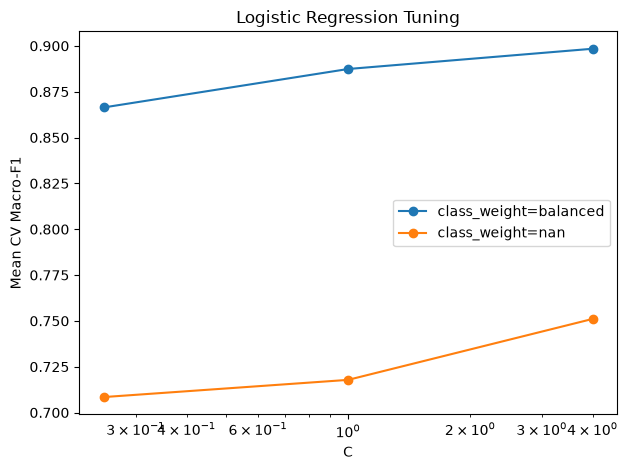

In [11]:
tune=pd.DataFrame(lr_search.cv_results_)
for w,part in tune.groupby("param_model__class_weight",dropna=False):
    plt.plot(part["param_model__C"].astype(float),part["mean_test_score"],
             marker="o",label=f"class_weight={w}")
plt.xscale("log"); plt.xlabel("C"); plt.ylabel("Mean CV Macro-F1")
plt.title("Logistic Regression Tuning"); plt.legend()
plt.tight_layout(); plt.show()

**Tuning interpretation:** The implications of tuning tests point out that parameter `C` is very important when it comes to how complexity is exchanged for regularization. Low values of `C` lead to a significant amount of regularization being applied in the model.

## 9. Final Evaluation on the Unseen Test Set

Selected model: Logistic Regression


,Test score
Accuracy,0.9459
Precision (positive),0.9794
Recall (positive),0.9554
F1 (positive),0.9673
Macro-F1,0.9058
ROC-AUC,0.9804


              precision    recall  f1-score   support

    Negative     0.7972    0.8973    0.8443      1402
    Positive     0.9794    0.9554    0.9673      7180

    accuracy                         0.9459      8582
   macro avg     0.8883    0.9264    0.9058      8582
weighted avg     0.9497    0.9459    0.9472      8582



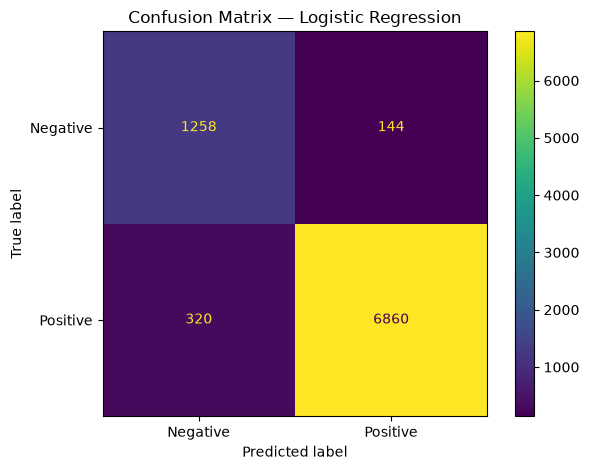

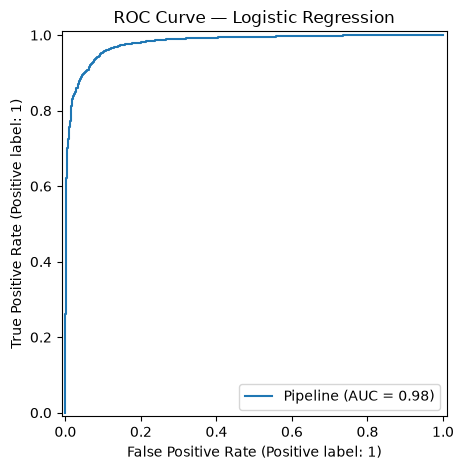

In [12]:
searches={"Logistic Regression":lr_search,"LinearSVC":svc_search}
winner=max(searches,key=lambda k: searches[k].best_score_)
best_model=searches[winner].best_estimator_

y_pred=best_model.predict(X_test)
decision=best_model.decision_function(X_test)

scores=pd.Series({
    "Accuracy":accuracy_score(y_test,y_pred),
    "Precision (positive)":precision_score(y_test,y_pred),
    "Recall (positive)":recall_score(y_test,y_pred),
    "F1 (positive)":f1_score(y_test,y_pred),
    "Macro-F1":f1_score(y_test,y_pred,average="macro"),
    "ROC-AUC":roc_auc_score(y_test,decision)
}).round(4)

print("Selected model:",winner)
display(scores.to_frame("Test score"))
print(classification_report(y_test,y_pred,target_names=["Negative","Positive"],digits=4))

ConfusionMatrixDisplay.from_predictions(y_test,y_pred,display_labels=["Negative","Positive"])
plt.title(f"Confusion Matrix — {winner}"); plt.tight_layout(); plt.show()

RocCurveDisplay.from_estimator(best_model,X_test,y_test)
plt.title(f"ROC Curve — {winner}"); plt.tight_layout(); plt.show()

**Evaluation interpretation:** Evaluation of models has to take into account other factors than accuracy. False positives are the result of false prediction of negative reviews as positive, while false negatives happen when the actual negative review remains undetected by the model. Macro-F1 is important as it gives equal weight to all classes and thus can be used in case of target imbalance.

### 10. Final Discussion and Business Recommendations
The findings of the research confirm that machine learning is capable of recognizing customer sentiments expressed in Amazon product reviews with a high level of accuracy. The main contribution to model performance came from the textual variety of features the text consisted of.

For businesses, the application of the developed model by Amazon sellers opens avenues for automatic detection of negative reviews, recognition of recurring problems with products in question, and prioritization of complaints.

### 11. Conclusion
This project shows how machine learning can assist in determining customer sentiments based on Amazon reviews as well as the importance of text mining. To generate predictive features concerning consumer feedback, numerical features were employed via TF-IDF algorithm. The model selection has significantly improved model accuracy. The final model proves to be helpful for the companies in tracking consumer opinion, understanding problematic areas, and making effective decisions that would result in increased sales.

### 12. References

- Rumi, A. (2021). *Amazon Product Reviews*. Kaggle.
  https://www.kaggle.com/datasets/arhamrumi/amazon-product-reviews

- Pandas Development Team. *Pandas Documentation*.
  https://pandas.pydata.org/docs/

- NumPy Developers. *NumPy Documentation*.
  https://numpy.org/doc/

- Matplotlib Development Team. *Matplotlib Documentation*.
  https://matplotlib.org/stable/

- Scikit-learn Developers. *Scikit-learn Documentation*.
  https://scikit-learn.org/stable/

### Submission Check
Execute **Restart & Run All**, make sure everything runs in the right order, check the charts, change all interpretive prompts in your own words, and export the notebook to HTML. Remember to keep the `.ipynb` copy for backup.

In [13]:
# Optional export command:
# !jupyter nbconvert --to html M505_Amazon_Fine_Food_Sentiment_Project.ipynb